### Inversion 

**Model revision (resolution-matched thicknesses)** — layer thicknesses are 5–20 / 10–30 / 15–40 / 15–35 m + half-space, so the cumulative finite thickness is ≤ 125 m. This keeps every inverted interface inside the ~100 m depth resolved by the 2–6 Hz Rayleigh data (confirmed by the sensitivity kernels), instead of letting the deepest interface wander to 175 m where the data has no sensitivity. Half-space Vs bound [0.50, 0.95] km/s (poorly constrained below ~100 m — report as a lower bound, don't interpret).

In [1]:
# Import necessary dependencies
import glob
import os
import sys
import numpy as np
np.Inf = np.inf 

import pickle
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d

from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

from evodcinv import EarthModel, Layer, Curve
from disba import PhaseDispersion
from disba import depthplot

sys.path.append('..')
from src.plots import plot_scatter_section
from src.inv import *

from IPython.display import HTML

import matplotlib as mpl
mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 100.0 

#### 1. Load and QC Inversion Inputs

In [2]:
# 1. Define the directory where you saved the files
input_dir = "../results/inv_inputs_urban"
inv_files = sorted(glob.glob(os.path.join(input_dir, "dispersion_*.txt")))

# Master lists to hold the loaded data
x_loaded = []
y_loaded = []
z_loaded = []

# 2. Loop through and load each file
for fpath in inv_files:
    fname = os.path.basename(fpath)
    
    # Extract the distance from the filename (e.g., "dispersion_0120m.txt" -> 120)
    try:
        # Split by '_' and remove 'm.txt' to get just the number
        dist_str = fname.split('_')[1].replace('m.txt', '')
        distance_m = float(dist_str)
    except (IndexError, ValueError):
        print(f"Skipping {fname}: could not parse distance.")
        continue
        
    # Load the 2-column text file, automatically ignoring the '#' header line
    # If using tab-delimited, np.loadtxt handles it natively
    data = np.loadtxt(fpath, comments='#')
    
    # Check if data was loaded correctly (requires at least 1 row)
    if data.ndim != 2 or data.shape[1] != 2:
        print(f"Warning: {fname} does not have the expected 2-column format.")
        continue
        
    f = data[:, 0]  # First column is Frequency
    v = data[:, 1]  # Second column is Phase Velocity
    
    # Append to master lists for mapping
    x_loaded.extend([distance_m] * len(f))
    y_loaded.extend(f)
    z_loaded.extend(v)

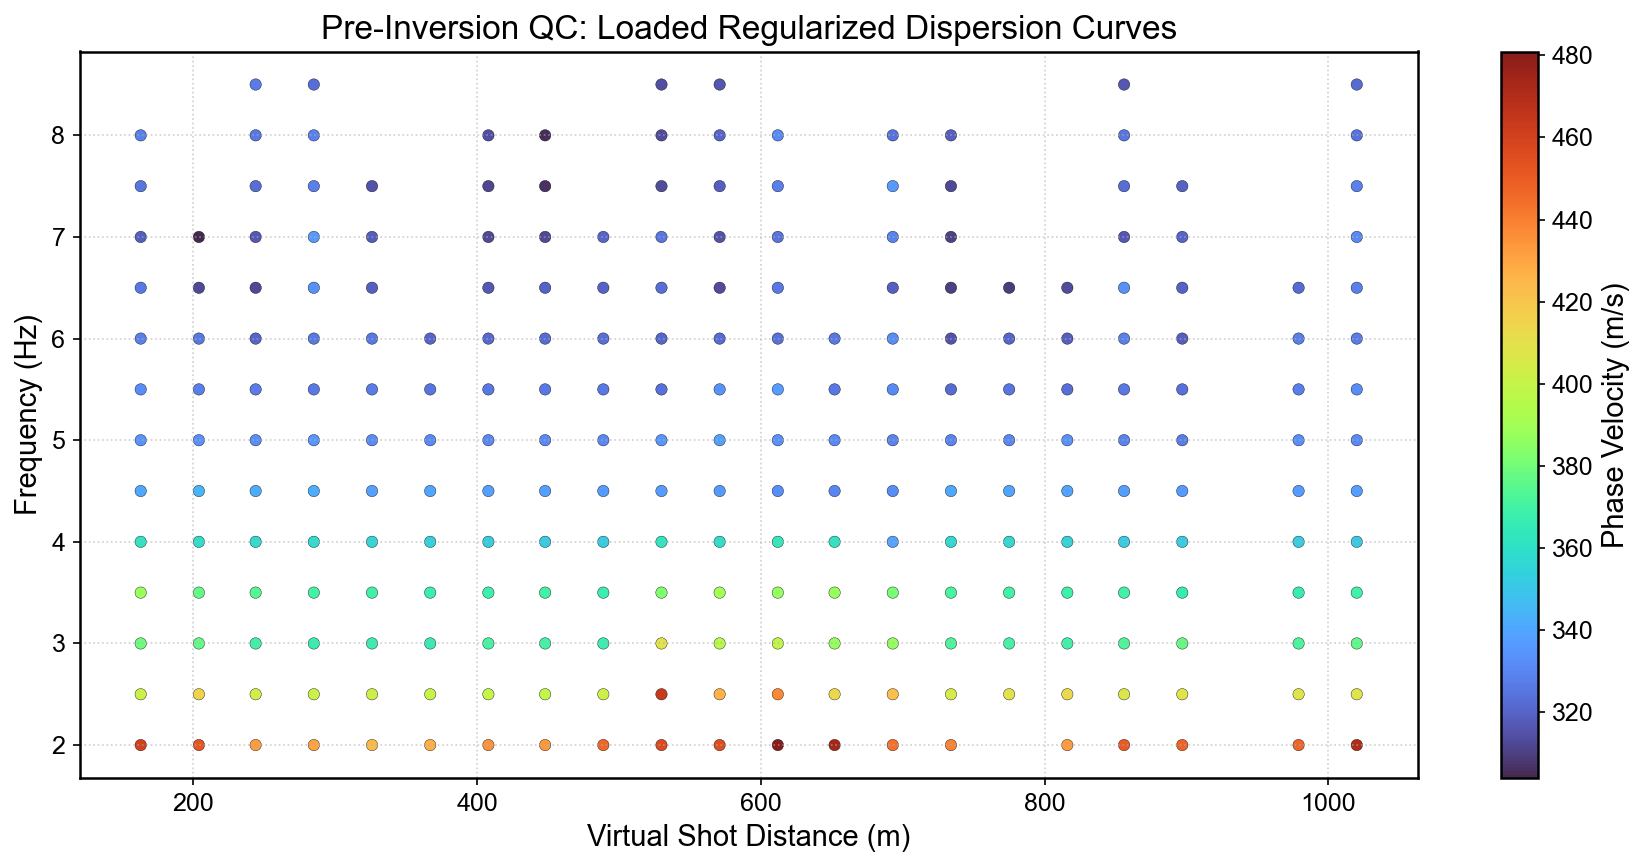

In [3]:
plot_scatter_section(x_loaded, y_loaded, z_loaded, title="Pre-Inversion QC: Loaded Regularized Dispersion Curves")

#### 2. Single-Station 1D Depth Inversion Test

Before we invert the entire DAS array, we need to parameterize our geological model and test our optimizer settings on a single virtual shot. 

In this step, we will:
1. **Load a single dispersion curve:** Read one of our exported `.txt` files.

2. **Convert Units:** `evodcinv` strictly requires **Period (seconds)** instead of Frequency (Hz), and **Phase Velocity in km/s** instead of m/s. It also requires the arrays to be sorted with the period in ascending order.

3. **Initialize the EarthModel:** We define the prior search boundaries for our geological layers (Thickness, S-wave velocity, and Poisson's ratio).

4. **Configure the Optimizer:** We set up the Particle Swarm Optimization (`cpso`), enforce an increasing velocity with depth to stabilize the inversion, and fix the density.

5. **Run & Visualize:** We execute the inversion and plot the resulting 1D shear-wave velocity ($V_s$) profile alongside the predicted vs. observed dispersion curve.

When we define a layer using `model.add(Layer([d_min, d_max], [vs_min, vs_max], [nu_min, nu_max]))`, we are setting the Prior Search Boundaries for the Particle Swarm Optimizer.

Example: `model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34]))`

- Argument 1: `[0.005, 0.020]` (Thickness in km): The algorithm is allowed to guess any thickness for this specific layer between 5 meters and 20 meters.

- Argument 2: `[0.10, 0.40]` (Shear Velocity $V_s$ in km/s): The algorithm can guess any velocity for this layer between 100 m/s and 400 m/s.

- Argument 3: `[0.32, 0.34]` (Poisson's Ratio, unitless): Constrains the $V_p/V_s$ relationship. We keep this tight because surface waves are primarily sensitive to $V_s$, not Poisson's ratio.

In [4]:
# 1. Load and Prepare the Data
test_file = "../results/inv_inputs_urban/dispersion_0163m.txt"
data = np.loadtxt(test_file, comments='#')

f_obs = data[:, 0]      # Frequency in Hz
v_obs_ms = data[:, 1]   # Velocity in m/s

# `evodcinv` requires Period (ascending order) and Velocity (km/s)
# Reversing the arrays [::-1] ensures period goes from low to high
disp_period = 1.0 / f_obs[::-1]  
disp_velocity = v_obs_ms[::-1] / 1000.0

# Define the curve object (Mode 0, Rayleigh wave)
curves = [Curve(disp_period, disp_velocity, mode=0)]

# 2. Build Model Search Boundaries
model = EarthModel()

# Add layers from top to bottom
# Arguments: [Thickness bounds in km], [Vs bounds in km/s], [Poisson's ratio bounds]
# Here we use ~50m thick layers, searching for Vs between 100 - 1000 m/s.

# Layer 1 (Surface soil): Thickness between 5m and 20m
# Cumulative Max Depth: 20m
model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34]))

# Layer 2 (Intermediate 1): Thickness between 10m and 30m
# Cumulative Max Depth: 20m + 30m = 50m
model.add(Layer([0.010, 0.030], [0.20, 0.55], [0.32, 0.34]))

# Layer 3 (Intermediate 2): Thickness between 10m and 35m
# Cumulative Max Depth: 50m + 35m = 85m
model.add(Layer([0.015, 0.040], [0.30, 0.65], [0.32, 0.34]))

# Layer 4 (Intermediate 3): Thickness between 15m and 35m
# Cumulative Max Depth: 85m + 35m = 120m
model.add(Layer([0.015, 0.035], [0.40, 0.80], [0.32, 0.34]))

# Layer 5 (Half-space/Bedrock starts somewhere between 40m and 120m)
# The thickness parameter here is required for syntax but acts as infinite depth.
model.add(Layer([0.050, 0.100], [0.50, 0.95], [0.32, 0.34]))

# 3. Configure the Optimizer
# Fix density to 1.0 g/cm^3 across all layers
f_rho = lambda x: 1.0 + 0.0 * x

model.configure(
    optimizer="cpso",           # Particle Swarm Optimization
    misfit="rmse",              # Root Mean Square Error
    density=f_rho,              # Apply fixed density
    increasing_velocity=True,   # Enforce no low-velocity zones (geological constraint)
    optimizer_args={
        "popsize": 20,          # Number of models per generation
        "maxiter": 1500,        # Maximum iterations per run
        "workers": -1,          # Use all available CPU cores
        "seed": 42,             # For reproducibility
    },
)

print("EarthModel and Optimizer configured successfully.")

EarthModel and Optimizer configured successfully.


#### 3. Run Inversion and Evaluate Results

Now we execute the inversion. Because evolutionary algorithms rely on random sampling, we run the inversion multiple times (`maxrun=5`) to ensure the solution converges on the global minimum rather than getting stuck in a local minimum.

After the inversion completes, we will visualize three things:
1. **Convergence Curve:** How the misfit drops over iterations.

2. **1D Velocity Profile:** The inverted $V_s$ vs. Depth.

3. **Curve Fitting:** How well our modeled dispersion curve matches the actual DAS observations.

In [5]:
# Rnn the inversion
print("Starting inversion... this may take a moment.")
res = model.invert(curves, maxrun=5)
print(res)

Run 1   |▏                   |   0% [0:00:00 / 0:00:25] - Misfit: 0.0083

Starting inversion... this may take a moment.


Run 1   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 2   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 3   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067


--------------------------------------------------------------------------------
Best model out of 150000 models (5 runs)

Velocity model                                    Model parameters
----------------------------------------          ------------------------------
         d        vp        vs       rho                   d        vs        nu
      [km]    [km/s]    [km/s]   [g/cm3]                [km]    [km/s]       [-]
----------------------------------------          ------------------------------
    0.0185    0.6623    0.3407    1.0000              0.0185    0.3407    0.3200
    0.0161    0.6905    0.3407    1.0000              0.0161    0.3407    0.3390
    0.0400    0.8775    0.4515    1.0000              0.0400    0.4515    0.3200
    0.0350    0.9168    0.4515    1.0000              0.0350    0.4515    0.3399
    1.0000    1.6516    0.8308    1.0000                   -    0.8308    0.3306
----------------------------------------          ------------------------------


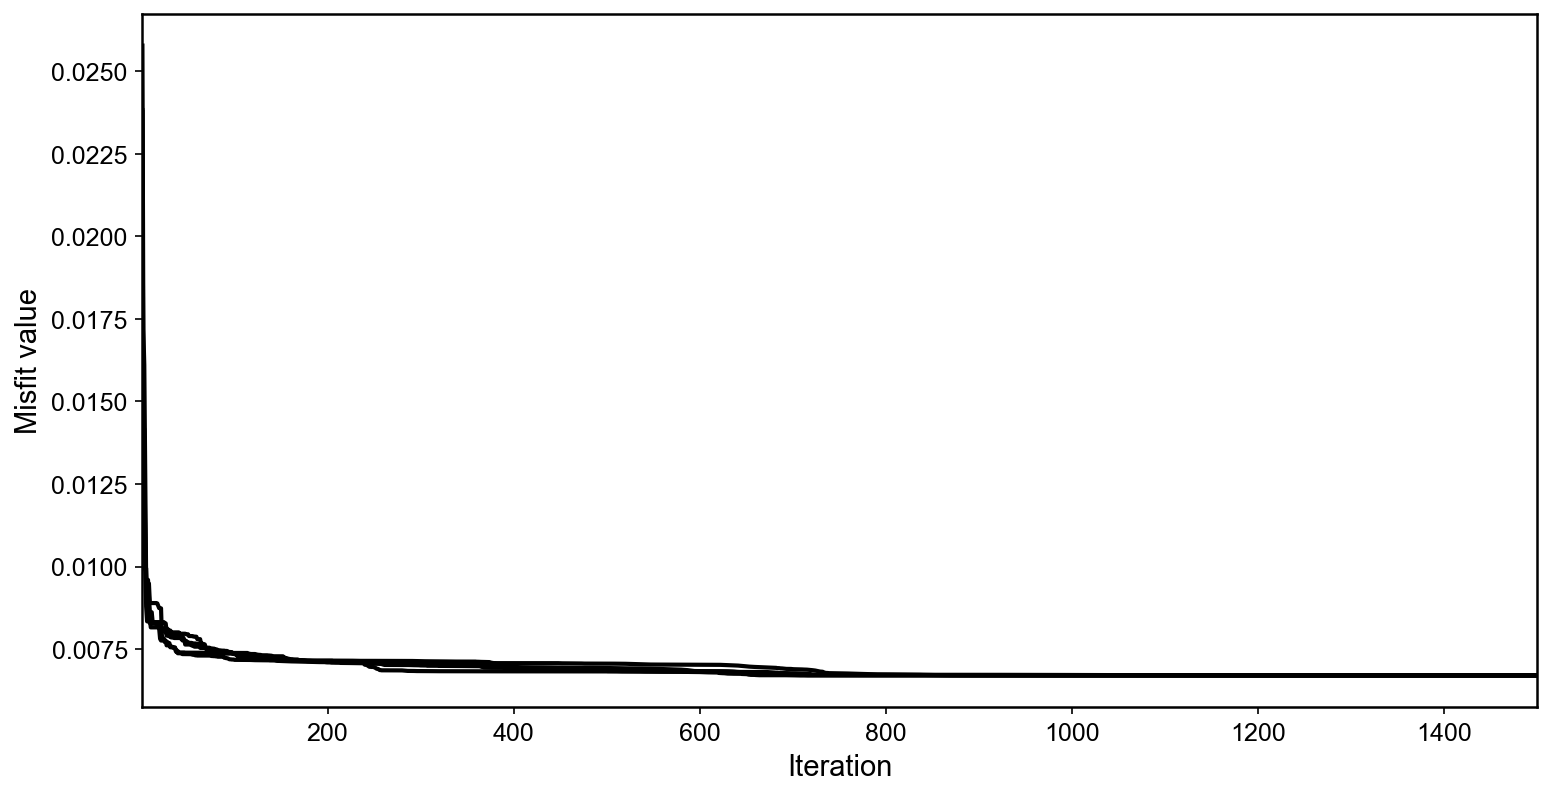

In [6]:
# Misfit convergence (built-in to evodcinv)
res.plot_misfit()
plt.show()

In [7]:
# Print statistics for the top 10% of models
print("\n--- Statistics for Top 10% of Models ---")
model_param_range(res, percent=10)


--- Statistics for Top 10% of Models ---
Evaluating 5 models from the ensemble.
--- Layer 0 ---
Thickness [km] : 0.0095, 0.0095, 0.0185, 0.0185, 0.0185
Vs [km/s]      : 0.3392, 0.3392, 0.3407, 0.3407, 0.3407
Poisson (Nu)   : 0.3200, 0.3200, 0.3209, 0.3384, 0.3400

--- Layer 1 ---
Thickness [km] : 0.0161, 0.0161, 0.0161, 0.0248, 0.0248
Vs [km/s]      : 0.3392, 0.3392, 0.3407, 0.3407, 0.3407
Poisson (Nu)   : 0.3355, 0.3390, 0.3390, 0.3399, 0.3399

--- Layer 2 ---
Thickness [km] : 0.0400, 0.0400, 0.0400, 0.0400, 0.0400
Vs [km/s]      : 0.4480, 0.4480, 0.4515, 0.4515, 0.4515
Poisson (Nu)   : 0.3200, 0.3200, 0.3200, 0.3201, 0.3202

--- Layer 3 ---
Thickness [km] : 0.0350, 0.0350, 0.0350, 0.0350, 0.0350
Vs [km/s]      : 0.4480, 0.4480, 0.4515, 0.4515, 0.4515
Poisson (Nu)   : 0.3200, 0.3200, 0.3399, 0.3399, 0.3399

--- Layer 4 ---
Vs [km/s]      : 0.8307, 0.8308, 0.8328, 0.8569, 0.8591
Poisson (Nu)   : 0.3306, 0.3306, 0.3306, 0.3400, 0.3400



#### 4. Plot the Inverted 1D Velocity Model

Plotting depth profiles for 15000 models.
Plotting mean of 45001 models.
Misfit range: 0.0067 to 0.0067


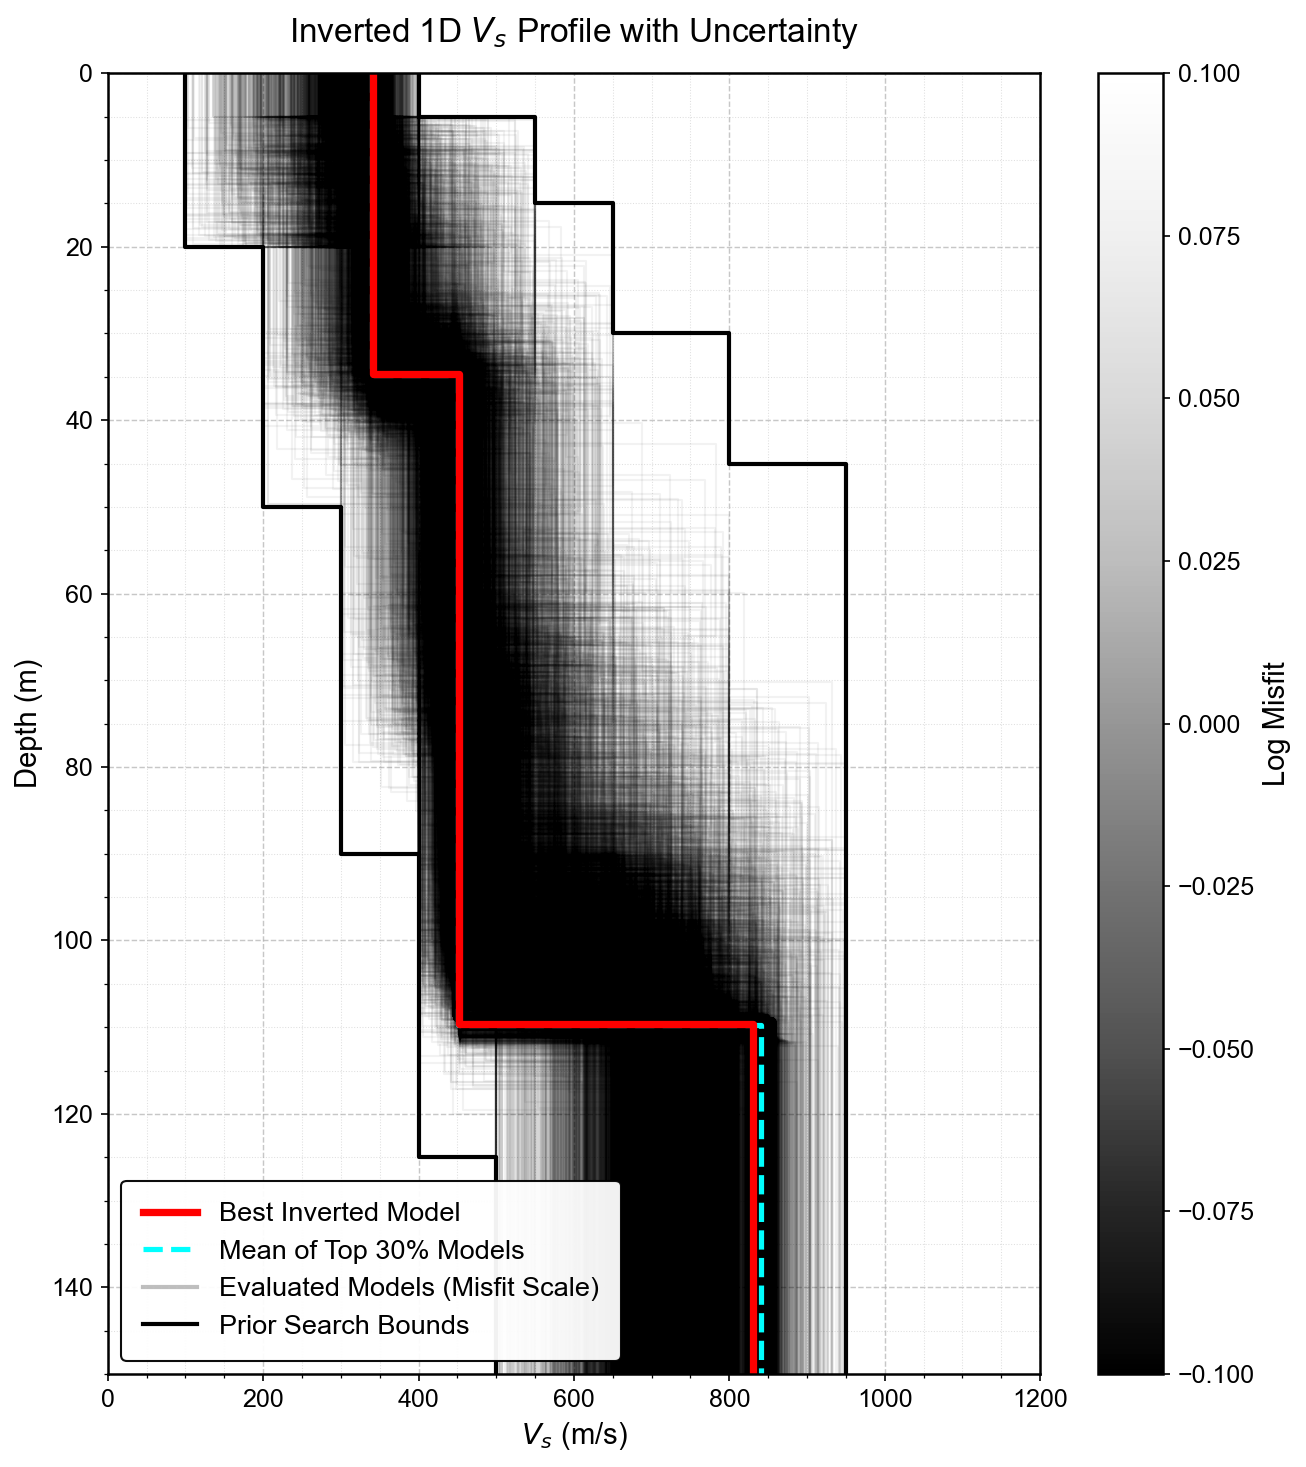

In [10]:
# 1. Make the figure taller and wider
fig, ax = plt.subplots(figsize=(9, 10))

# 2. Add major AND minor grids for easier depth/velocity reading
ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)
ax.minorticks_on()

# A. Plot the Search Boundaries (Prior) - Black solid lines
plot_model_range(
    model, 
    plot_args={"color": "black", "linestyle": "-", "linewidth": 2}, 
    ax=ax
)

# B. Plot ALL Models (Ensemble) - Thin, transparent, grayscale colorbar
# Using Greys_r so lower misfit (better models) are darker.
plot_model(
    res, parameter="vs", show="percentage", percent=100, stride=10, zmax=150, 
    cmap_on=True, plot_args={"cmap": "Greys_r", "alpha": 0.05, "linewidth": 1}, ax=ax
)

# C. Plot the Mean of the Top 30% Models - Dashed blue line
plot_model(
    res, parameter="vs", show="mean", percent=30, zmax=150,
    plot_args={"color": "cyan", "linewidth": 2.5, "linestyle": "--"}, ax=ax
)

# D. Plot the Single Best Model on top - Bold red line
plot_model(
    res, parameter="vs", show="best", zmax=150, 
    plot_args={"color": "red", "linewidth": 3.5, "linestyle": "-"}, ax=ax
)

# 3. Enhanced Typography
ax.set_title("Inverted 1D $V_s$ Profile with Uncertainty", pad=15)
ax.set_xlabel("$V_s$ (m/s)")
ax.set_ylabel("Depth (m)")
ax.tick_params(axis='both', which='major')

# Optional: Add a bit of padding to the x-axis so the bounds don't touch the frame
ax.set_xlim([0, 1200]) 

# 4. Create a Custom Legend
legend_elements = [
    Line2D([0], [0], color='red', lw=3.5, linestyle='-', label='Best Inverted Model'),
    Line2D([0], [0], color='cyan', lw=2.5, linestyle='--', label='Mean of Top 30% Models'),
    Line2D([0], [0], color='gray', lw=2, alpha=0.5, label='Evaluated Models (Misfit Scale)'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='Prior Search Bounds')
]

ax.legend(
    handles=legend_elements, 
    loc='lower left',        
    fontsize=13, 
    framealpha=0.95,         
    edgecolor='black',
    borderpad=0.8
)

plt.tight_layout()
plt.show()

Plotting curves from 15001 models.


Calculating Curves: 100%|██████████| 15001/15001 [00:06<00:00, 2457.28it/s] 


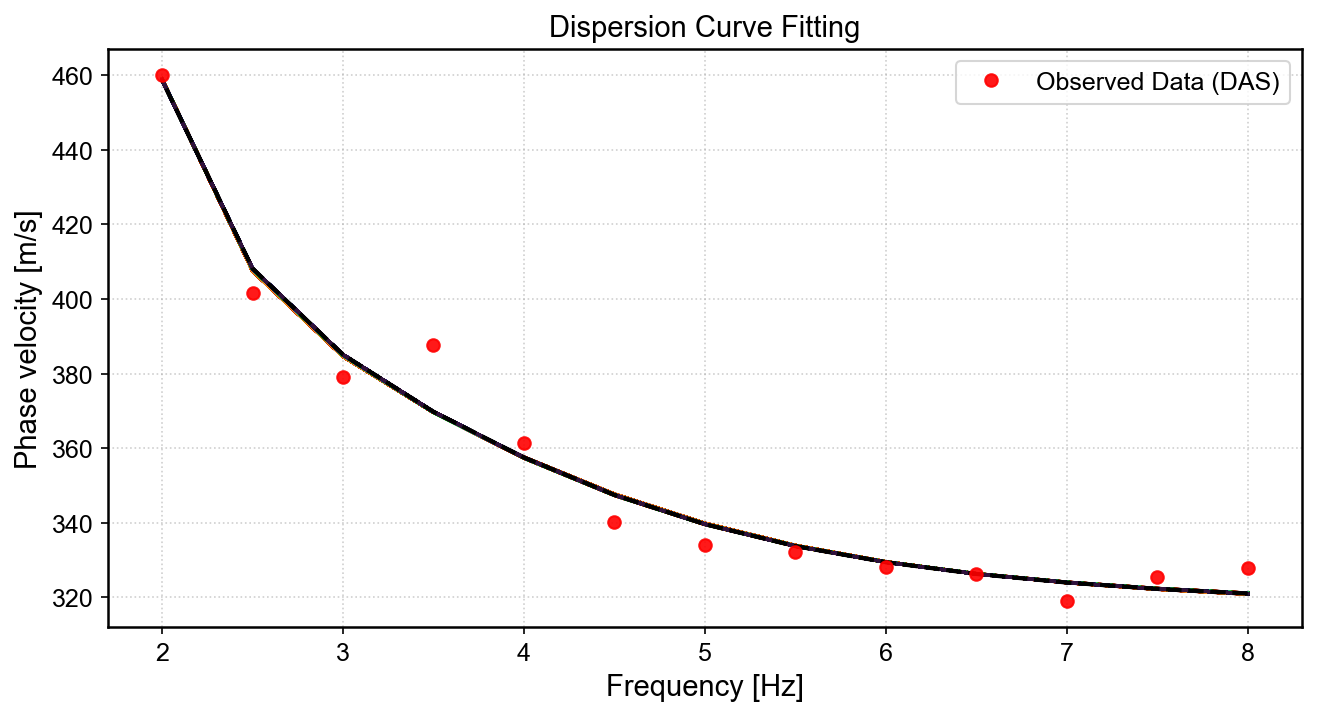

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# A. Plot the ensemble of theoretical dispersion curves
plot_predicted_curve(
    res, disp_period, mode=0, wave='rayleigh', curve_type='phase', 
    show="percentage", percent=10, 
    plot_args={"xaxis": "frequency", "cmap": "turbo", "alpha": 0.1}, ax=ax
)

# B. Plot the single best theoretical curve
plot_predicted_curve(
    res, disp_period, mode=0, wave='rayleigh', curve_type='phase', 
    show="best", 
    plot_args={"xaxis": "frequency", "color": "black", "linewidth": 2, "linestyle": "--"}, ax=ax
)

# C. Overlay the actual DAS observations
ax.plot(f_obs, v_obs_ms, 'ro', label='Observed Data (DAS)', markersize=6, alpha=0.9)

ax.grid(True, linestyle=':', alpha=0.6)
# Fix legend to avoid duplicate labels from the ensemble
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=12)

ax.set_title("Dispersion Curve Fitting", fontsize=14)
plt.tight_layout()
plt.show()

#### 5. Run Inversion for All Virtual Shots

In [11]:
input_dir = "../results/inv_inputs_urban"
out_dir = "../results/inv_outputs_urban"
os.makedirs(out_dir, exist_ok=True)

# Find all txt files and sort them alphabetically (which sorts them by distance)
file_list = sorted(glob.glob(os.path.join(input_dir, "dispersion_*.txt")))

# Create a regular depth grid from 0 to 120m (1-meter resolution)
max_depth = 120  # Maximum depth in meters
z_grid = np.arange(0, max_depth + 1, 1)  # Depth grid from 0 to 120m with 1m intervals

# Initialize lists to hold the results
positons = []
vs_2d_matrix_mean = []
vs_2d_matrix_best = []
all_results = []

In [12]:
for i, file_path in enumerate(file_list):
    # Extract the distance from the filename
    basename = os.path.basename(file_path)
    distance_str = ''.join(filter(str.isdigit, basename))
    dist = float(distance_str)
    positons.append(dist)

    print(f"Processing {i+1}/{len(file_list)}: Station at {dist}m", end=" ")

    # Load and convert data
    data = np.loadtxt(file_path, comments='#')
    f_obs = data[:, 0]      
    v_obs_ms = data[:, 1]   

    disp_period = 1.0 / f_obs[::-1]
    disp_velocity = v_obs_ms[::-1] / 1000.0
    curves = [Curve(disp_period, disp_velocity, 0, "rayleigh")]

    # Build the EarthModel
    model = EarthModel()
    model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34])) 
    model.add(Layer([0.010, 0.030], [0.20, 0.55], [0.32, 0.34])) 
    model.add(Layer([0.015, 0.040], [0.30, 0.65], [0.32, 0.34])) 
    model.add(Layer([0.015, 0.035], [0.40, 0.80], [0.32, 0.34])) 
    model.add(Layer([0.050, 0.100], [0.50, 0.95], [0.32, 0.34])) 

    model.configure(
        optimizer="cpso",           
        misfit="rmse",              
        density=lambda x: 1.0 + 0.0 * x,              
        increasing_velocity=True,   
        optimizer_args={"popsize": 20, "maxiter": 1500, "workers": -1, "seed": 42}
    )

    # Run the inversion.
    res = model.invert(curves, maxrun=5)
    all_results.append(res)
    
    # ---------------------------------------------------------
    # 1. Process and Interpolate the BEST Model
    # ---------------------------------------------------------
    # Save 1D text file for best model
    out_file = os.path.join(out_dir, f"1D_model_best_{dist}m.txt")
    np.savetxt(out_file, res.model, header="Thickness(km) Vp(km/s) Vs(km/s) Density(g/cm3)", fmt="%.6f")

    thicknesses_best = res.model[:, 0] * 1000  
    vs_best = res.model[:, 2] * 1000  

    # FIX: nodes at layer TOPS (drop the half-space's nominal 1 km thickness);
    # the half-space Vs then fills everything below the deepest interface.
    # The old code prepended vs_best[0] onto a depth axis that INCLUDED that
    # 1 km, which shifted every layer one step deeper and pushed the bedrock Vs
    # off the 0-120 m grid entirely.
    tops_best = np.insert(np.cumsum(thicknesses_best[:-1]), 0, 0)

    f_interp_best = interp1d(tops_best, vs_best, kind='previous', fill_value=(vs_best[0], vs_best[-1]), bounds_error=False)
    vs_2d_matrix_best.append(f_interp_best(z_grid))

    # ---------------------------------------------------------
    # 2. Process and Interpolate the MEAN Model (Top 30%)
    # ---------------------------------------------------------
    # NOTE: The get_mean_model function prints its own lines, so we add a newline first to keep the console clean
    print(f"| Best Misfit: {res.misfit:.4f}")
    mean_model = get_mean_model(res, percent=30)
    
    thicknesses_mean = mean_model[:, 0] * 1000  
    vs_mean = mean_model[:, 2] * 1000  

    # FIX: same layer-top correction for the mean (top-30%) model.
    tops_mean = np.insert(np.cumsum(thicknesses_mean[:-1]), 0, 0)

    f_interp_mean = interp1d(tops_mean, vs_mean, kind='previous', fill_value=(vs_mean[0], vs_mean[-1]), bounds_error=False)
    vs_2d_matrix_mean.append(f_interp_mean(z_grid))

    # Pickle the entire result object
    res_filepath = os.path.join(out_dir, f"inv_result_{dist}m.pkl")
    with open(res_filepath, 'wb') as f:
        pickle.dump(res, f)

# Convert lists to NumPy arrays for plotting 
positions = np.array(positons)
matrix_best = np.array(vs_2d_matrix_best).T   # Transpose: rows=Depth, columns=Distance
matrix_mean = np.array(vs_2d_matrix_mean).T   # Transpose: rows=Depth, columns=Distance

# Save BOTH matrices into a single compressed .npz file
np.savez(os.path.join(out_dir, "final_2D_matrix.npz"), 
         vs_matrix_best=matrix_best, 
         vs_matrix_mean=matrix_mean,
         positions=positions, 
         z_grid=z_grid)

all_res_filepath = os.path.join(out_dir, "all_results_list.pkl")
with open(all_res_filepath, "wb") as f:
    pickle.dump(all_results, f)
    
print("\nSaved all InversionResult objects and 2D matrices successfully!")

Run 1   |▏                   |   1% [0:00:00 / 0:00:19] - Misfit: 0.0083

Processing 1/21: Station at 163.0m 

Run 1   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 2   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 3   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0067
Run 1   |▏                   |   0% [0:00:00 / 0:00:19] - Misfit: 0.0053

| Best Misfit: 0.0067
Extracted mean of top 45001 models.
Misfit range: 0.0067 to 0.0067
Processing 2/21: Station at 204.0m 

Run 1   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0043
Run 2   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0043
Run 3   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0044
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0044
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0043
Run 1   |▏                   |   0% [0:00:00 / 0:00:20] - Misfit: 0.0072

...

| Best Misfit: 0.0026
Extracted mean of top 45001 models.
Misfit range: 0.0026 to 0.0026
Processing 20/21: Station at 979.0m 

Run 1   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 2   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 3   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0030
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 1   |▏                   |   0% [0:00:00 / 0:00:20] - Misfit: 0.0036

| Best Misfit: 0.0030
Extracted mean of top 45001 models.
Misfit range: 0.0030 to 0.0031
Processing 21/21: Station at 1020.0m 

Run 1   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0032
Run 2   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 3   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0031
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0032


| Best Misfit: 0.0031
Extracted mean of top 45001 models.
Misfit range: 0.0031 to 0.0032

Saved all InversionResult objects and 2D matrices successfully!


#### Corrected 2D $V_s$ section (fixed depth mapping + lateral interpolation + physical smoothing)


Figure successfully saved to: ../results/inv_outputs_urban/contour_2D_profile.png


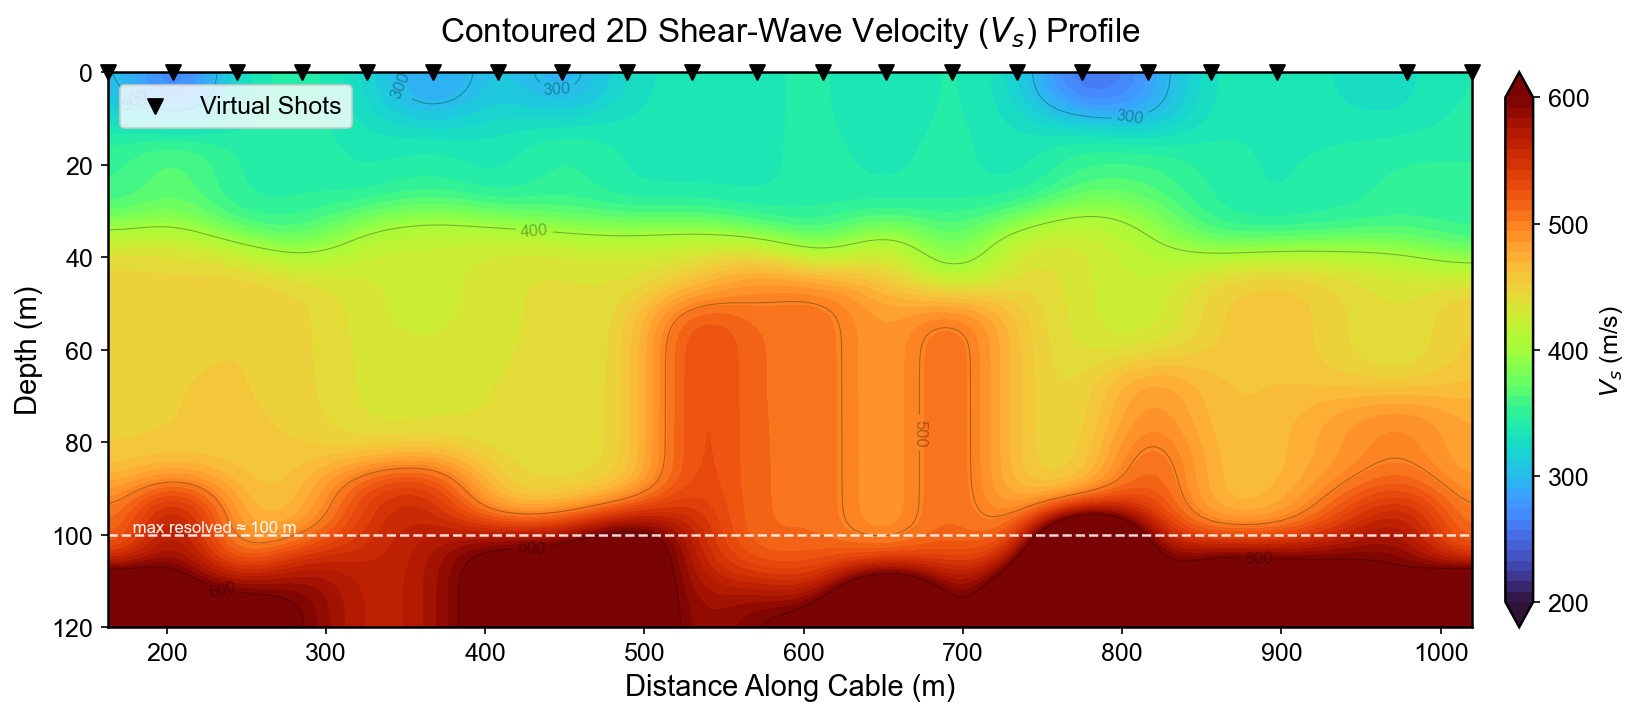

In [31]:
from src.inv import plot_2d_contour_section

#  - depth mapping fixed in the inversion loop (layer tops; half-space Vs below)
#  - x_interp_step: interpolate the 11 sparse shots onto a ~2 m grid BEFORE contouring
#    (removes the vertical banding)
#  - smooth_units='physical': smooth_sigma is (sigma_z, sigma_x) in METRES
#  - max_resolved_depth: 2-6 Hz data -> longest wavelength ~Vmax/fmin ~250 m
#    -> max reliable depth ~ lambda/2.5 ~ 100 m (below this the half-space is poorly constrained)

plot_2d_contour_section(
    positions, z_grid, vs_2d_matrix_mean,
    max_depth=120, vmin=200, vmax=600,
    x_interp_step=2.0,
    smooth_sigma=(5.0, 20.0),   # (sigma_z, sigma_x) in metres  
    smooth_units='physical',     
    max_resolved_depth=100,
    contour=True, x_flip=False,
    save_path="../results/inv_outputs_urban/contour_2D_profile.png",
)

#### 6. Run Inversion Results

In [ ]:
# Load the saved 2D matrix and metadata
saved_data = np.load("../results/inv_outputs_urban/final_2D_matrix.npz")
vs_2d_matrix_best = saved_data['vs_matrix_best']
vs_2d_matrix_mean = saved_data['vs_matrix_mean']
positions = saved_data['positions']
z_grid = saved_data['z_grid']

# Load the entire list of InversionResult objects back into memory
with open("../results/inv_outputs_urban/all_results_list.pkl", "rb") as f:
    all_results = pickle.load(f)

# Re-define the prior model bounds just in case the notebook restarted
model = EarthModel()
model.add(Layer([0.005, 0.020], [0.10, 0.40], [0.32, 0.34])) 
model.add(Layer([0.010, 0.030], [0.20, 0.55], [0.32, 0.34])) 
model.add(Layer([0.015, 0.040], [0.30, 0.65], [0.32, 0.34])) 
model.add(Layer([0.015, 0.035], [0.40, 0.80], [0.32, 0.34])) 
model.add(Layer([0.050, 0.100], [0.50, 0.95], [0.32, 0.34]))

In [32]:
print("Saving all profile plots to disk...")

for i, res in enumerate(tqdm(all_results)):
    dist = positions[i]
    save_profile_plot(
        res=res, 
        prior_model=model, 
        dist=dist,
        save_dir="../results/inv_profiles_urban"
    )

print("Done saving all images!")

Saving all profile plots to disk...


  0%|          | 0/21 [00:00<?, ?it/s]

Plotting depth profiles for 15000 models.
Plotting mean of 45001 models.
Misfit range: 0.0067 to 0.0067


  5%|▍         | 1/21 [00:46<15:34, 46.71s/it]

Plotting depth profiles for 15000 models.
Plotting mean of 45001 models.
Misfit range: 0.0043 to 0.0044


...

Plotting depth profiles for 15000 models.
Plotting mean of 45001 models.
Misfit range: 0.0030 to 0.0031


 95%|█████████▌| 20/21 [15:47<00:49, 49.91s/it]

Plotting depth profiles for 15000 models.
Plotting mean of 45001 models.
Misfit range: 0.0031 to 0.0032


100%|██████████| 21/21 [16:34<00:00, 47.34s/it]

Done saving all images!


**Convert notebook to html**
```bash
python3 -m jupyter nbconvert --to html inv_urban.ipynb
```